# E-commerce Sales Performance Analysis

 **Tools:** Python, pandas, matplotlib, seaborn

This notebook is my end-to-end analysis of two years of order data for an
online retail business — from raw transactions to stakeholder-ready insights.

**Business questions we're answering:**
1. How are revenue and profit trending month over month?
2. Which product categories and regions drive the business — and at what margin?
3. Are discounts helping or hurting profitability?
4. Who are our most valuable products and customers?

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
})

DATA_PATH = Path("ecommerce_sales.csv")   # relative so it works in Jupyter
VISUALS_DIR = Path("visuals")
VISUALS_DIR.mkdir(exist_ok=True)

print("Setup complete. Ready to analyze.")


Setup complete. Ready to analyze.


## 1. Load the data

First, let's load the order-level dataset and get a feel for its shape.

In [4]:
df = pd.read_csv(DATA_PATH, parse_dates=["order_date"])
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


Dataset shape: 2,000 rows x 13 columns


,order_id,order_date,customer_id,region,category,sub_category,product,quantity,unit_price,discount,sales,profit,payment_method
0,ORD-101070,2024-01-01,CUST-00391,West,Beauty,Skincare,HydraBoost Moisturizer,1,1234.37,0.1,1110.93,498.10,UPI
1,ORD-101945,2024-01-01,CUST-00595,East,Electronics,Laptop,AirBook Slim,1,80111.49,0.1,72100.34,5701.57,Cash on Delivery
2,ORD-100664,2024-01-02,CUST-00549,East,Electronics,Mobile,Galaxy Nova X5,1,24219.42,0.1,21797.48,2187.61,UPI
3,ORD-101555,2024-01-02,CUST-00220,North,Home & Kitchen,Appliances,ColdBrew Coffee Maker,1,6807.91,0.0,6807.91,2498.96,Credit Card
4,ORD-101584,2024-01-03,CUST-00095,North,Beauty,Skincare,Vitamin C Serum,1,924.01,0.1,831.61,394.97,UPI


In [5]:
# Quick profile: dtypes, non-null counts, and summary stats
df.info()
print()
print("Date range:", df["order_date"].min().date(), "to", df["order_date"].max().date())
df.describe(include="all").T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        2000 non-null   object        
 1   order_date      2000 non-null   datetime64[ns]
 2   customer_id     2000 non-null   object        
 3   region          2000 non-null   object        
 4   category        2000 non-null   object        
 5   sub_category    2000 non-null   object        
 6   product         2000 non-null   object        
 7   quantity        2000 non-null   int64         
 8   unit_price      2000 non-null   float64       
 9   discount        2000 non-null   float64       
 10  sales           2000 non-null   float64       
 11  profit          2000 non-null   float64       
 12  payment_method  2000 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(7)
memory usage: 203.3+ KB

Date range: 2024-01-01 to 202

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
order_id,2000,2000,ORD-101070,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_date,2000,NaN,NaN,NaN,2024-10-03 01:46:33.599999744,2024-01-01 00:00:00,2024-05-31 00:00:00,2024-10-06 00:00:00,2025-02-03 00:00:00,2025-06-30 00:00:00,NaN
customer_id,2000,573,CUST-00380,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,2000,4,North,571,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,2000,5,Beauty,426,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sub_category,2000,13,Makeup,221,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product,2000,27,Matte Lipstick Set,112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quantity,2000.0,NaN,NaN,NaN,1.8035,1.0,1.0,1.0,2.0,5.0,1.11423
unit_price,2000.0,NaN,NaN,NaN,11021.131625,854.14,1333.0925,3364.84,9538.2125,82917.31,19204.898838
discount,2000.0,NaN,NaN,NaN,0.091875,0.0,0.0,0.05,0.15,0.4,0.09173


## 2. Clean and validate the data

Before any analysis: drop duplicates, remove rows missing key fields, guard
against impossible values (negative quantities/prices), and cap discounts.
I'll also derive `order_month` and `profit_margin` for the analysis below.

In [6]:
before = len(df)

df = df.drop_duplicates()
df = df.dropna(subset=["order_id", "order_date", "sales", "profit"])
df = df[(df["quantity"] > 0) & (df["unit_price"] > 0) & (df["sales"] >= 0)]
df["discount"] = df["discount"].clip(0, 0.9)

df["order_month"] = df["order_date"].dt.to_period("M").astype(str)
df["profit_margin"] = np.where(df["sales"] > 0, df["profit"] / df["sales"], 0)

print(f"Removed {before - len(df)} bad rows -> {len(df):,} clean rows kept")
print(f"Clean date range: {df['order_date'].min().date()} to {df['order_date'].max().date()}")


Removed 0 bad rows -> 2,000 clean rows kept
Clean date range: 2024-01-01 to 2025-06-30


## 3. KPI dashboard

The headline numbers every stakeholder asks for first.

In [7]:
total_revenue = df["sales"].sum()
total_profit = df["profit"].sum()
total_orders = df["order_id"].nunique()
total_customers = df["customer_id"].nunique()
aov = total_revenue / total_orders
avg_margin = total_profit / total_revenue

print(f"""
============ KPI SUMMARY ============
Total Revenue         : Rs {total_revenue:,.0f}
Total Profit          : Rs {total_profit:,.0f}
Overall Profit Margin : {avg_margin:.1%}
Total Orders          : {total_orders:,}
Unique Customers      : {total_customers:,}
Average Order Value   : Rs {aov:,.0f}
=====================================""")



============ KPI SUMMARY ============
Total Revenue         : Rs 35,928,969
Total Profit          : Rs 5,182,912
Overall Profit Margin : 14.4%
Total Orders          : 2,000
Unique Customers      : 573
Average Order Value   : Rs 17,964


## 4. Exploratory analysis

### 4.1 Monthly revenue and profit trend

Is the business growing? Are revenue and profit moving together?

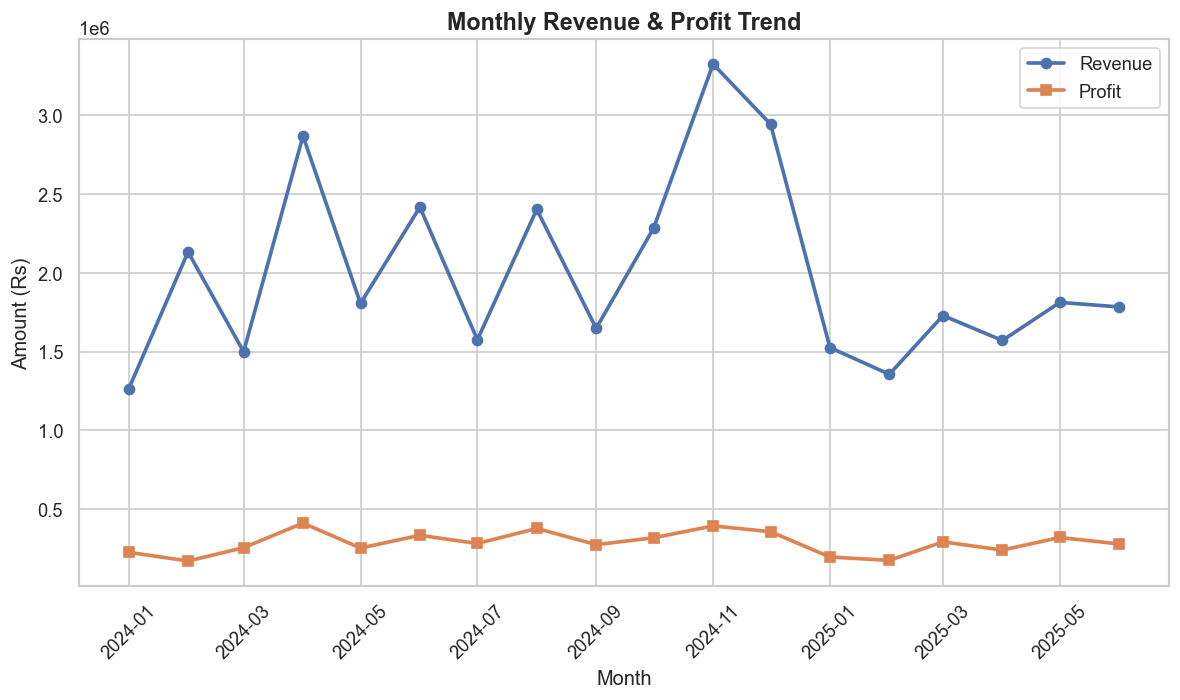

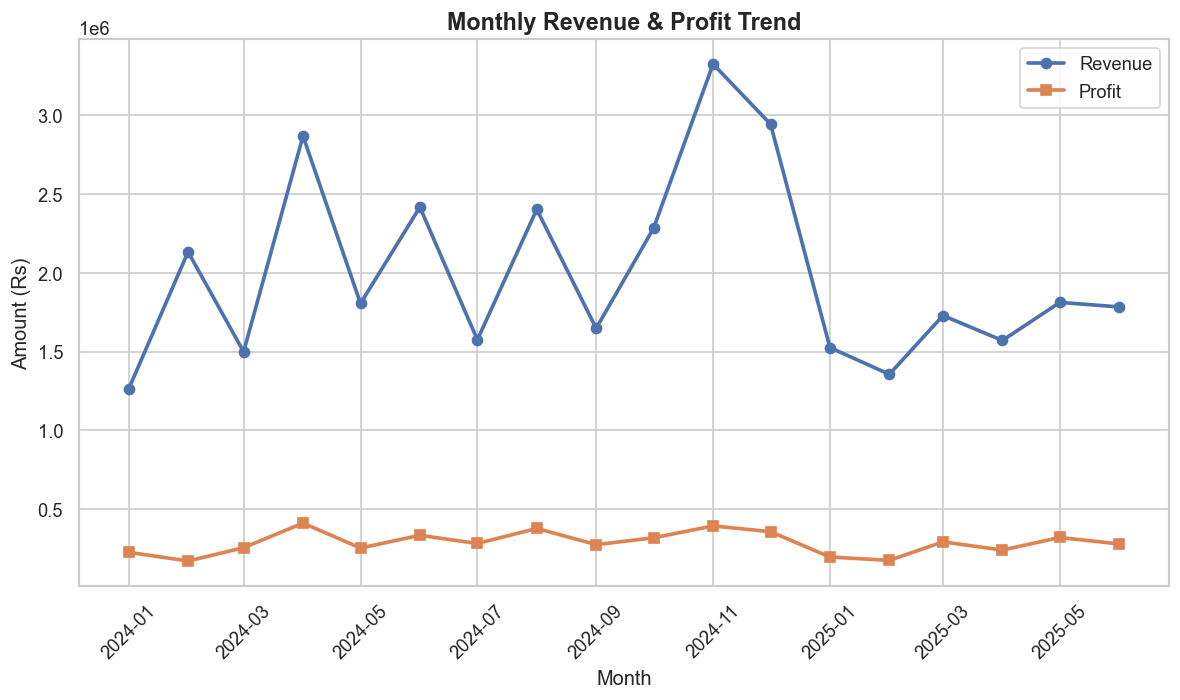

In [8]:
monthly = (df.groupby("order_month")
             .agg(revenue=("sales", "sum"), profit=("profit", "sum"),
                  orders=("order_id", "nunique"))
             .reset_index())
monthly["order_month"] = pd.to_datetime(monthly["order_month"])

fig, ax = plt.subplots()
ax.plot(monthly["order_month"], monthly["revenue"], marker="o",
        linewidth=2.2, label="Revenue")
ax.plot(monthly["order_month"], monthly["profit"], marker="s",
        linewidth=2.2, label="Profit")
ax.set_title("Monthly Revenue & Profit Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Amount (Rs)")
ax.legend()
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(VISUALS_DIR / "01_monthly_trend.png", dpi=150)
fig


### 4.2 Category performance

Revenue tells us where the money comes from — margin tells us where the
*profit* comes from. The gap between the two is often the biggest insight.

In [9]:
cat = (df.groupby("category")
         .agg(revenue=("sales", "sum"), profit=("profit", "sum"),
              orders=("order_id", "nunique"))
         .sort_values("revenue", ascending=False)
         .reset_index())
cat["margin"] = cat["profit"] / cat["revenue"]

display_df = cat.copy()
display_df["revenue"] = display_df["revenue"].map("Rs {:,.0f}".format)
display_df["profit"] = display_df["profit"].map("Rs {:,.0f}".format)
display_df["margin"] = display_df["margin"].map("{:.1%}".format)
display_df


,category,revenue,profit,orders,margin
0,Electronics,"Rs 25,774,936","Rs 2,300,711",418,8.9%
1,Home & Kitchen,"Rs 3,935,872","Rs 938,010",362,23.8%
2,Sports,"Rs 3,864,047","Rs 1,090,565",379,28.2%
3,Fashion,"Rs 1,517,003","Rs 469,450",415,30.9%
4,Beauty,"Rs 837,111","Rs 384,176",426,45.9%


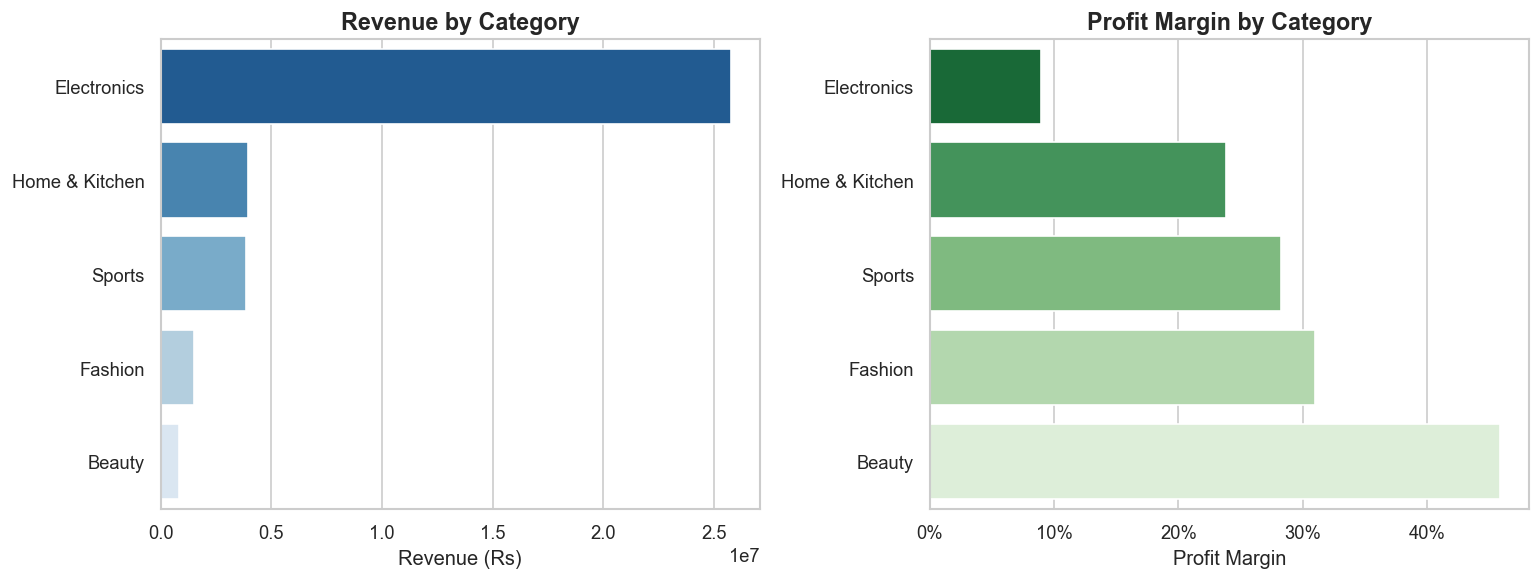

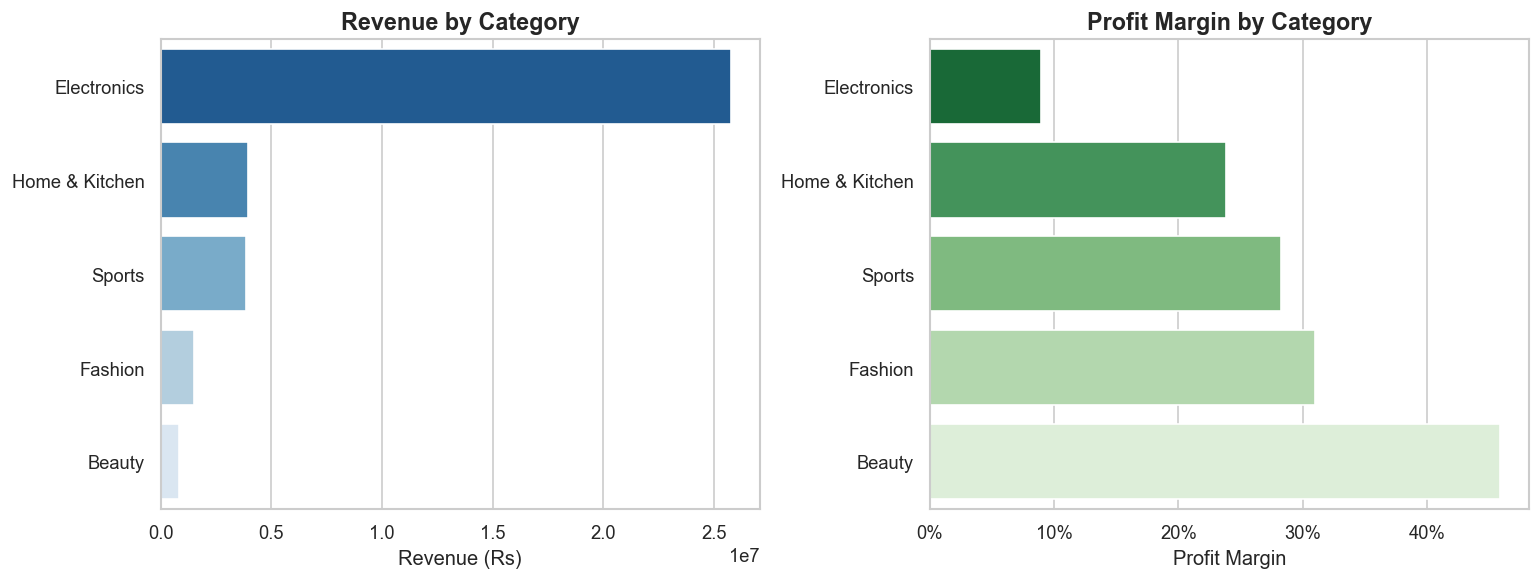

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=cat, x="revenue", y="category", hue="category",
            legend=False, ax=axes[0], palette="Blues_r")
axes[0].set_title("Revenue by Category")
axes[0].set_xlabel("Revenue (Rs)")
axes[0].set_ylabel("")
sns.barplot(data=cat, x="margin", y="category", hue="category",
            legend=False, ax=axes[1], palette="Greens_r")
axes[1].set_title("Profit Margin by Category")
axes[1].set_xlabel("Profit Margin")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
fig.tight_layout()
fig.savefig(VISUALS_DIR / "02_category_performance.png", dpi=150)
fig


### 4.3 Region performance

Where geographically is the business strongest, and where is the average
order value highest?

In [11]:
reg = (df.groupby("region")
         .agg(revenue=("sales", "sum"), profit=("profit", "sum"),
              orders=("order_id", "nunique"))
         .sort_values("revenue", ascending=False)
         .reset_index())
reg["aov"] = reg["revenue"] / reg["orders"]

display_df = reg.copy()
for c in ["revenue", "profit", "aov"]:
    display_df[c] = display_df[c].map("Rs {:,.0f}".format)
display_df


,region,revenue,profit,orders,aov
0,South,"Rs 10,405,345","Rs 1,533,093",544,"Rs 19,127"
1,North,"Rs 9,876,246","Rs 1,334,224",571,"Rs 17,296"
2,East,"Rs 8,643,214","Rs 1,321,543",480,"Rs 18,007"
3,West,"Rs 7,004,163","Rs 994,052",405,"Rs 17,294"


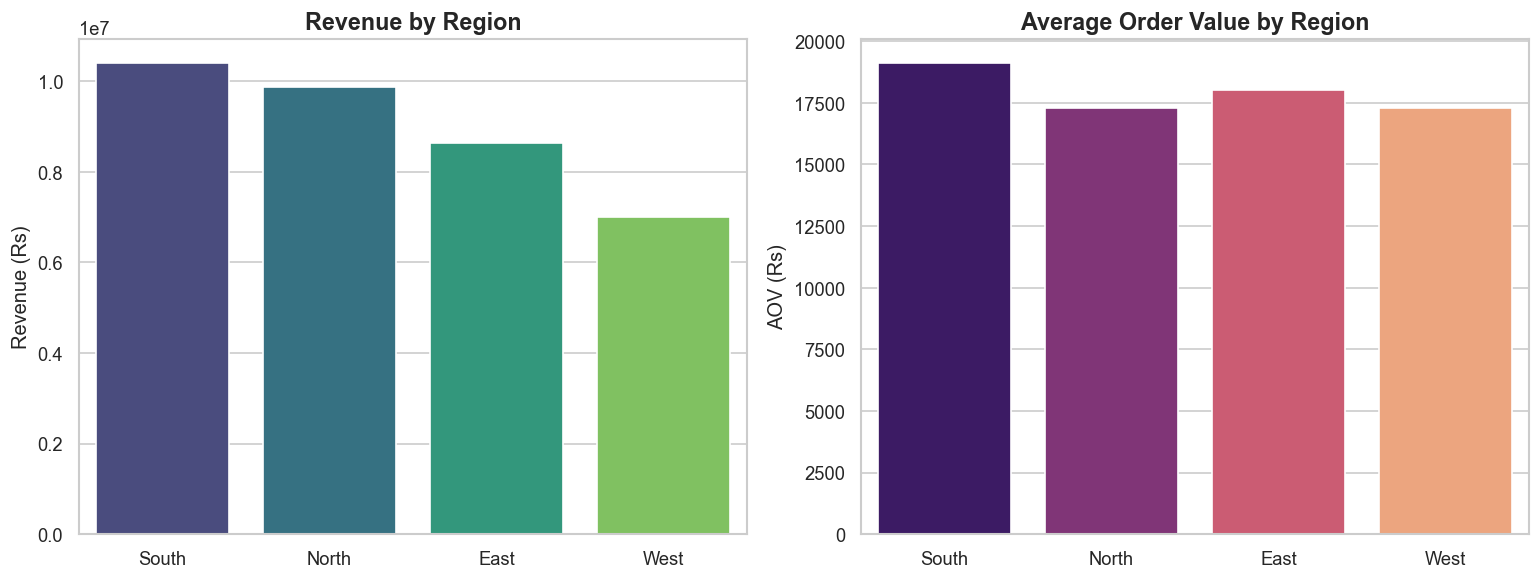

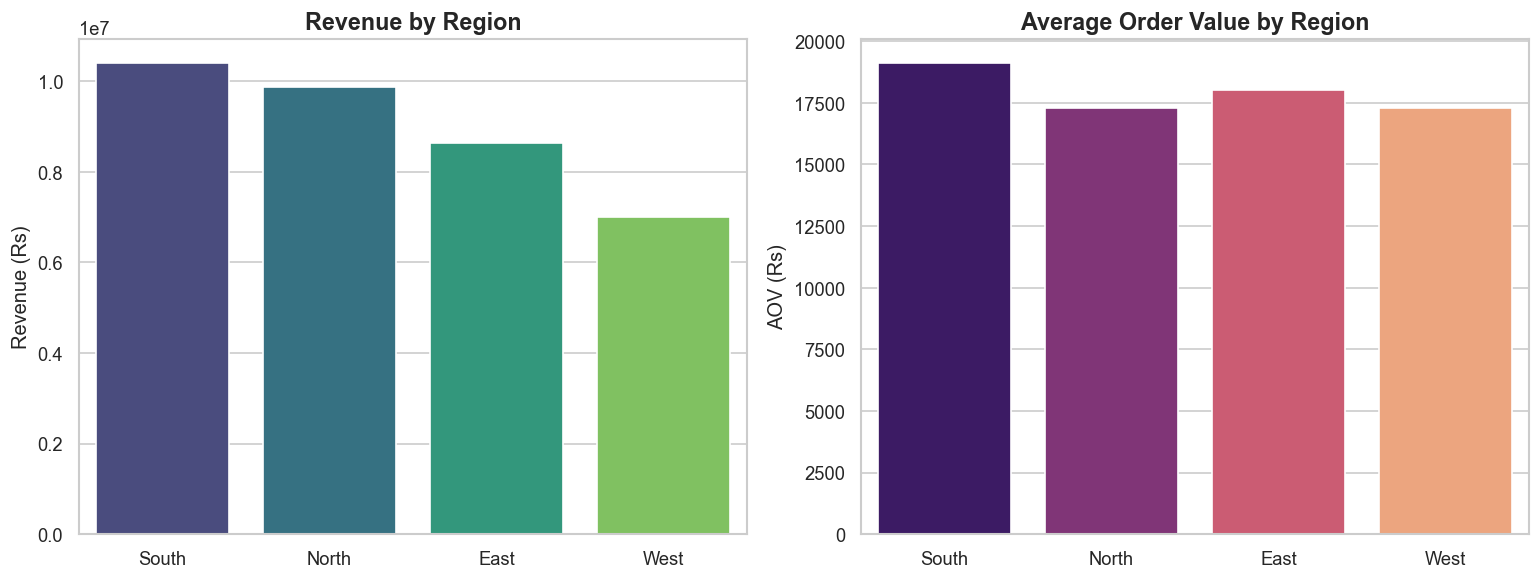

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=reg, x="region", y="revenue", hue="region",
            legend=False, ax=axes[0], palette="viridis")
axes[0].set_title("Revenue by Region")
axes[0].set_xlabel("")
axes[0].set_ylabel("Revenue (Rs)")
sns.barplot(data=reg, x="region", y="aov", hue="region",
            legend=False, ax=axes[1], palette="magma")
axes[1].set_title("Average Order Value by Region")
axes[1].set_xlabel("")
axes[1].set_ylabel("AOV (Rs)")
fig.tight_layout()
fig.savefig(VISUALS_DIR / "03_region_performance.png", dpi=150)
fig


### 4.4 Discount vs profit

Discounts drive volume — but at what cost? Let's bucket orders by discount
level and check the average margin in each bucket.

In [13]:
df["discount_bin"] = pd.cut(df["discount"],
                            bins=[-0.01, 0.0, 0.10, 0.20, 0.30, 1.0],
                            labels=["0%", "1-10%", "11-20%", "21-30%", "30%+"])
disc = (df.groupby("discount_bin", observed=True)
          .agg(orders=("order_id", "count"),
               avg_margin=("profit_margin", "mean"),
               total_profit=("profit", "sum"))
          .reset_index())

display_df = disc.copy()
display_df["avg_margin"] = display_df["avg_margin"].map("{:.1%}".format)
display_df["total_profit"] = display_df["total_profit"].map("Rs {:,.0f}".format)
display_df


,discount_bin,orders,avg_margin,total_profit
0,0%,605,36.9%,"Rs 2,860,138"
1,1-10%,790,29.4%,"Rs 2,267,747"
2,11-20%,410,18.0%,"Rs 303,911"
3,21-30%,162,6.4%,"Rs -139,269"
4,30%+,33,-10.2%,"Rs -109,616"


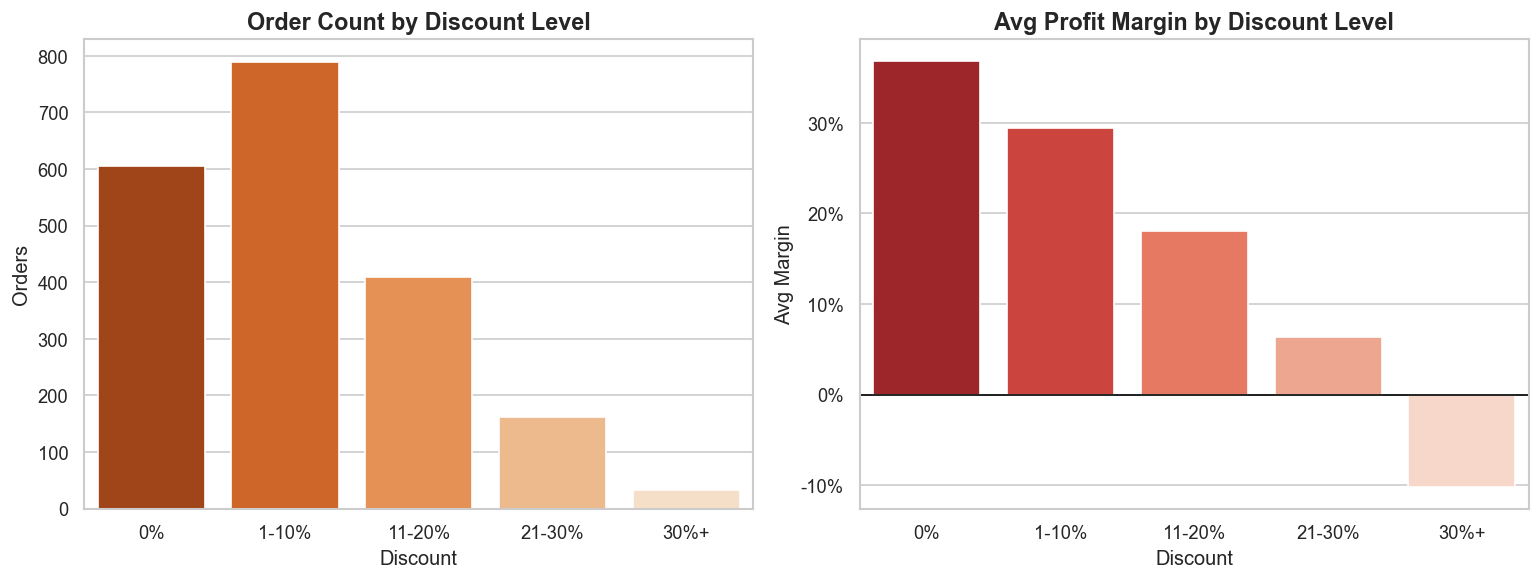

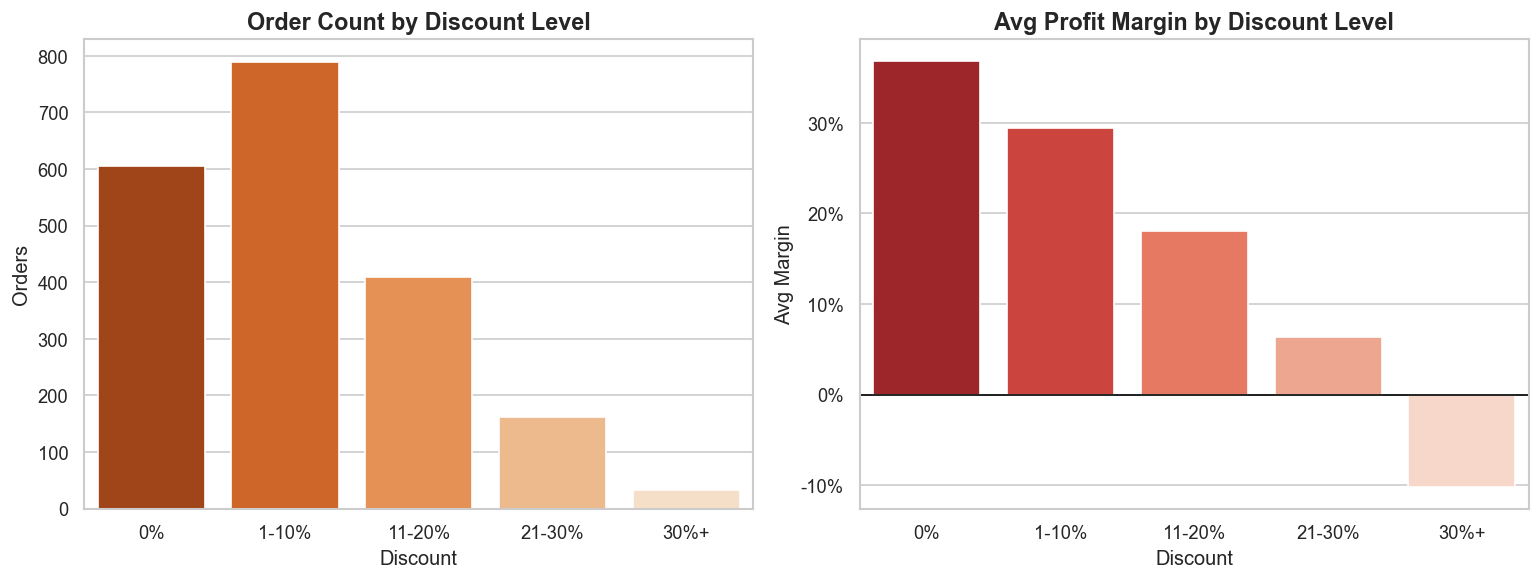

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=disc, x="discount_bin", y="orders", hue="discount_bin",
            legend=False, ax=axes[0], palette="Oranges_r")
axes[0].set_title("Order Count by Discount Level")
axes[0].set_xlabel("Discount")
axes[0].set_ylabel("Orders")
sns.barplot(data=disc, x="discount_bin", y="avg_margin", hue="discount_bin",
            legend=False, ax=axes[1], palette="Reds_r")
axes[1].set_title("Avg Profit Margin by Discount Level")
axes[1].set_xlabel("Discount")
axes[1].set_ylabel("Avg Margin")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
fig.tight_layout()
fig.savefig(VISUALS_DIR / "04_discount_vs_profit.png", dpi=150)
fig


### 4.5 Top products

Which individual products bring in the most revenue?

In [15]:
top_products = (df.groupby("product")
                  .agg(revenue=("sales", "sum"), profit=("profit", "sum"),
                       units=("quantity", "sum"))
                  .sort_values("revenue", ascending=False)
                  .head(10)
                  .reset_index())

display_df = top_products.copy()
display_df["revenue"] = display_df["revenue"].map("Rs {:,.0f}".format)
display_df["profit"] = display_df["profit"].map("Rs {:,.0f}".format)
display_df


,product,revenue,profit,units
0,AirBook Slim,"Rs 8,854,919","Rs 662,939",125
1,iPhone Zeta,"Rs 5,410,322","Rs 501,789",85
2,ThinkPro 14,"Rs 4,946,850","Rs 529,658",97
3,Pixel Aura 12,"Rs 2,951,501","Rs 290,514",98
4,Galaxy Nova X5,"Rs 1,727,724","Rs 133,007",77
5,AllWeather Tent 4P,"Rs 1,605,605","Rs 479,314",146
6,Adjustable Dumbbell 24kg,"Rs 1,503,984","Rs 398,124",170
7,BassBoom Speaker,"Rs 1,283,749","Rs 134,199",154
8,Oakwood Study Desk,"Rs 1,230,513","Rs 287,977",104
9,ErgoComfort Chair,"Rs 903,265","Rs 238,937",108


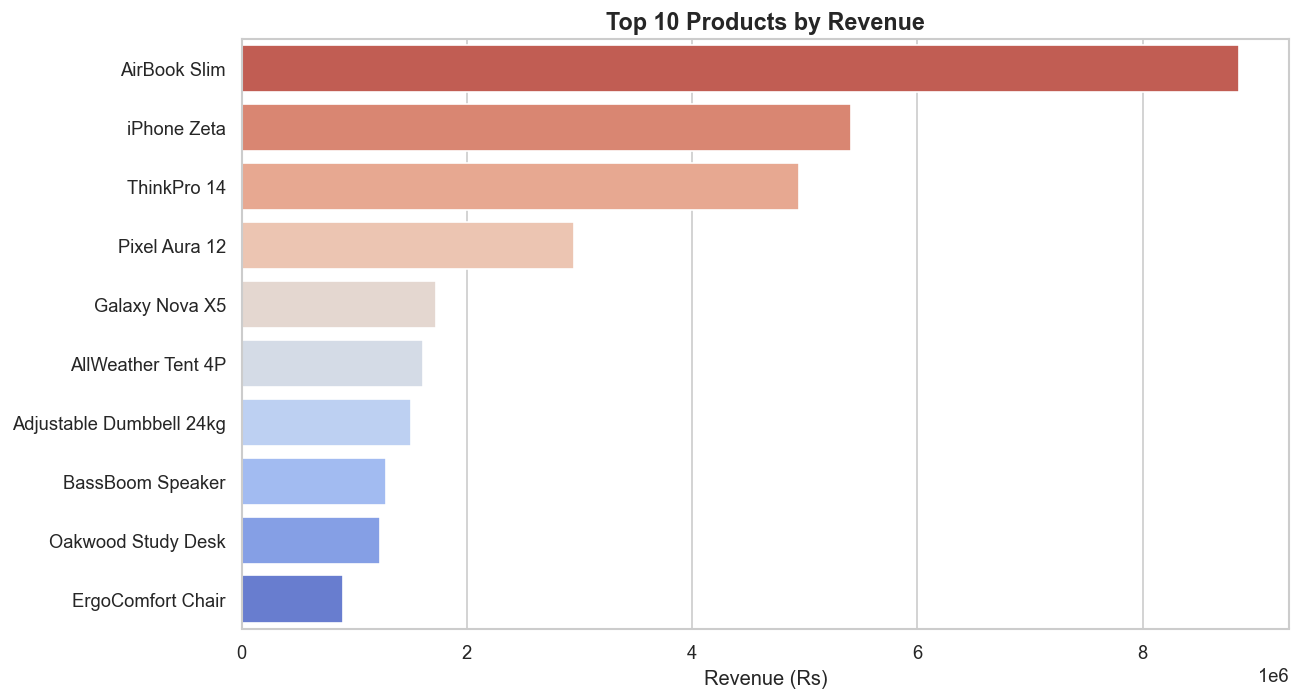

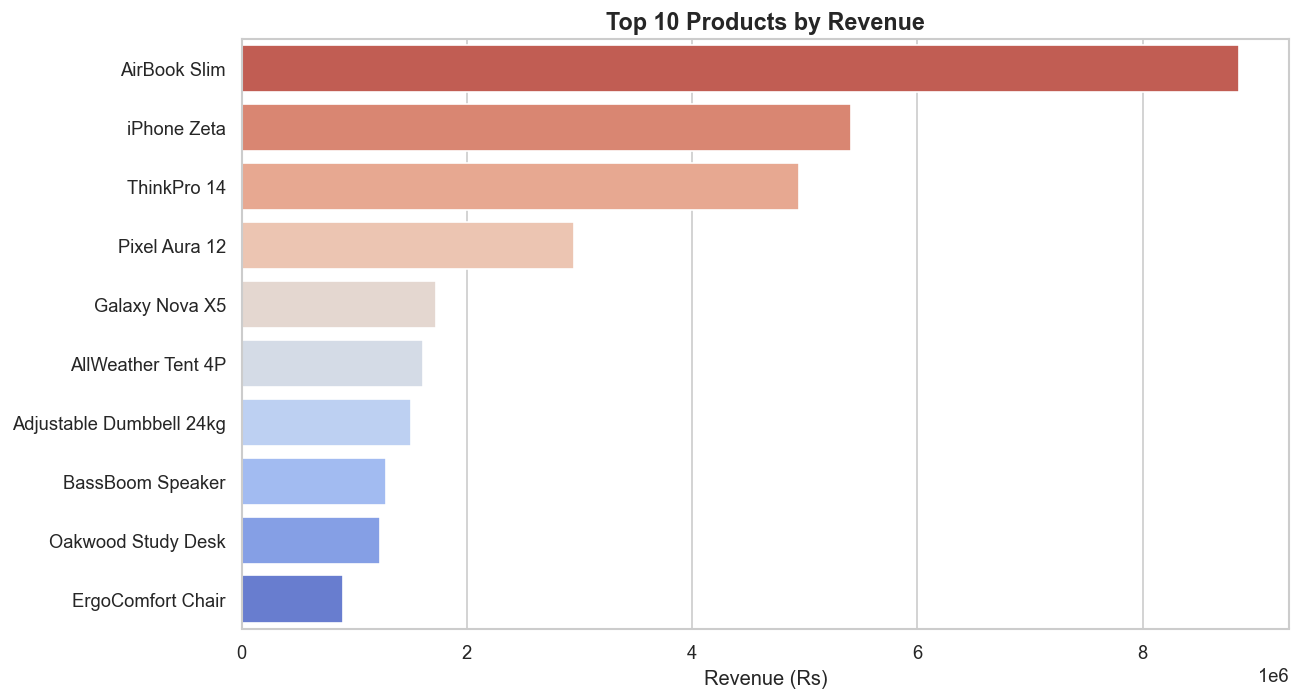

In [16]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=top_products, x="revenue", y="product", hue="product",
            legend=False, ax=ax, palette="coolwarm_r")
ax.set_title("Top 10 Products by Revenue")
ax.set_xlabel("Revenue (Rs)")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(VISUALS_DIR / "05_top_products.png", dpi=150)
fig


### 4.6 Customer insights

How loyal are customers? Is revenue concentrated in a small group of buyers?
And how do they prefer to pay?

In [17]:
cust = (df.groupby("customer_id")
          .agg(orders=("order_id", "nunique"),
               revenue=("sales", "sum"),
               profit=("profit", "sum"))
          .reset_index())
repeat_rate = (cust["orders"] > 1).mean()
top_10pct_n = max(1, int(len(cust) * 0.10))
top10_share = cust.nlargest(top_10pct_n, "revenue")["revenue"].sum() / total_revenue
pay = (df.groupby("payment_method")
         .agg(orders=("order_id", "count"), revenue=("sales", "sum"))
         .sort_values("orders", ascending=False)
         .reset_index())

print(f"Repeat purchase rate          : {repeat_rate:.1%}")
print(f"Revenue from top 10% customers: {top10_share:.1%}")
print()
display_df = pay.copy()
display_df["revenue"] = display_df["revenue"].map("Rs {:,.0f}".format)
display_df


Repeat purchase rate          : 88.5%
Revenue from top 10% customers: 41.2%



,payment_method,orders,revenue
0,UPI,865,"Rs 15,873,664"
1,Credit Card,540,"Rs 9,278,351"
2,Debit Card,293,"Rs 5,185,736"
3,Net Banking,152,"Rs 3,273,815"
4,Cash on Delivery,150,"Rs 2,317,403"


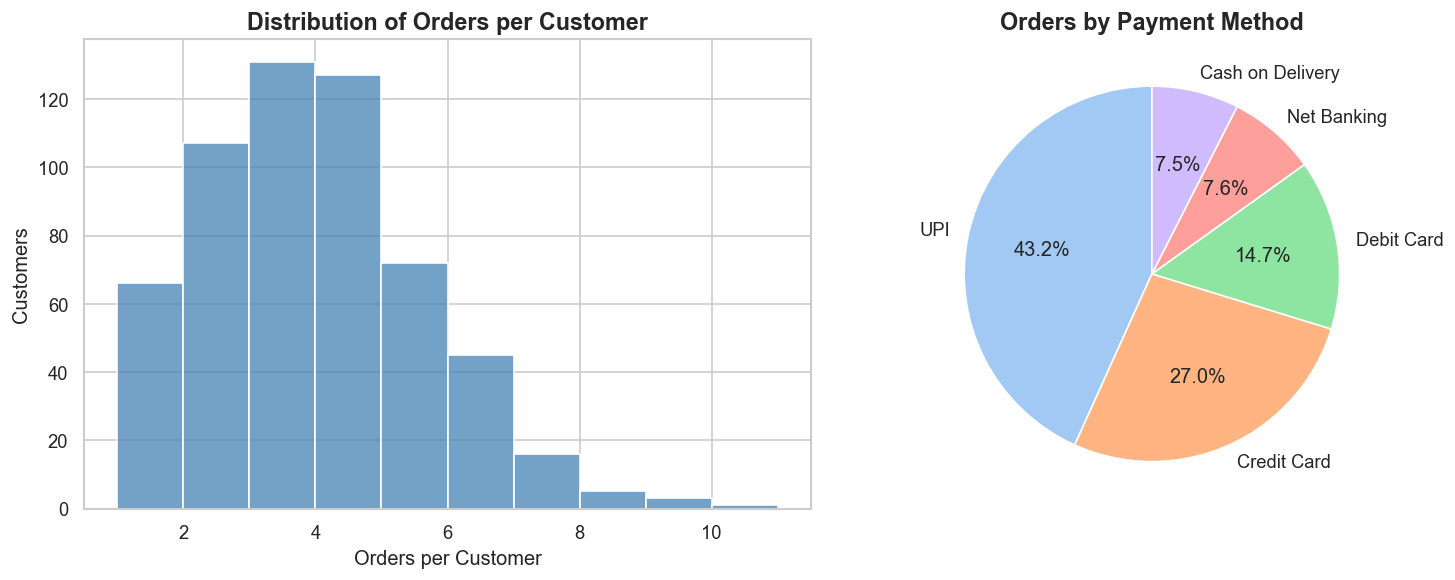

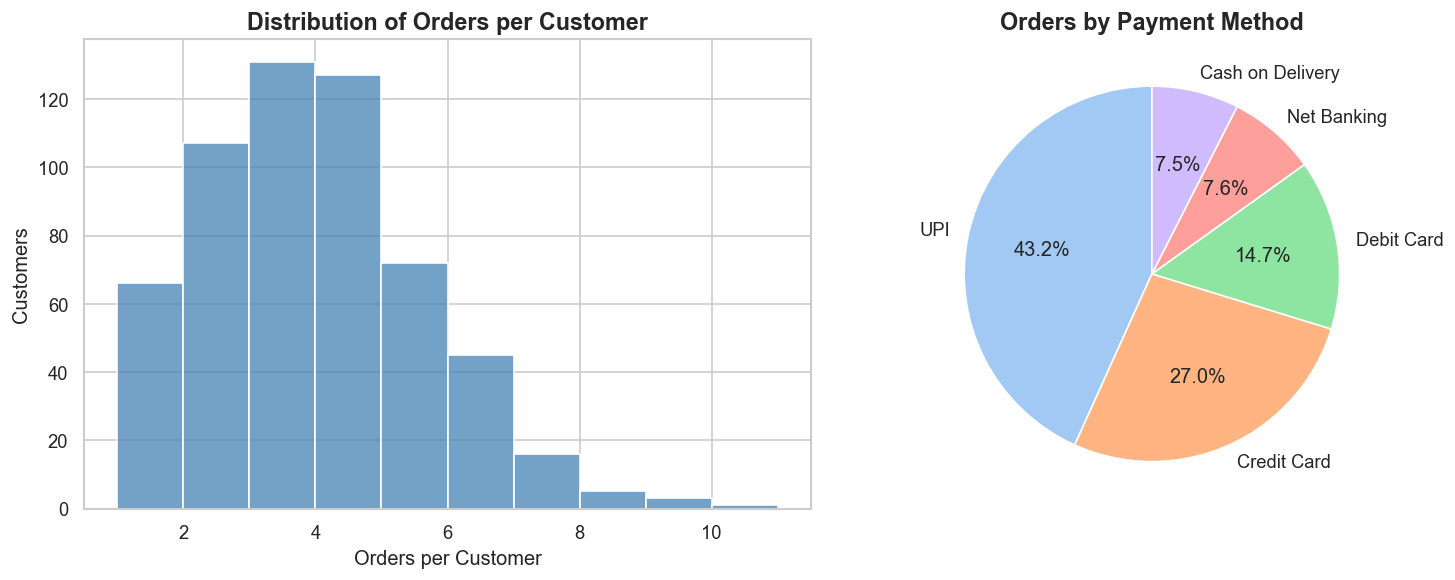

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(cust["orders"], bins=range(1, cust["orders"].max() + 2),
             kde=False, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Orders per Customer")
axes[0].set_xlabel("Orders per Customer")
axes[0].set_ylabel("Customers")
axes[1].pie(pay["orders"], labels=pay["payment_method"], autopct="%1.1f%%",
            startangle=90, colors=sns.color_palette("pastel"))
axes[1].set_title("Orders by Payment Method")
fig.tight_layout()
fig.savefig(VISUALS_DIR / "06_customer_insights.png", dpi=150)
fig


### 4.7 Margin heatmap: category x region

Where exactly is margin strongest and weakest across the business?

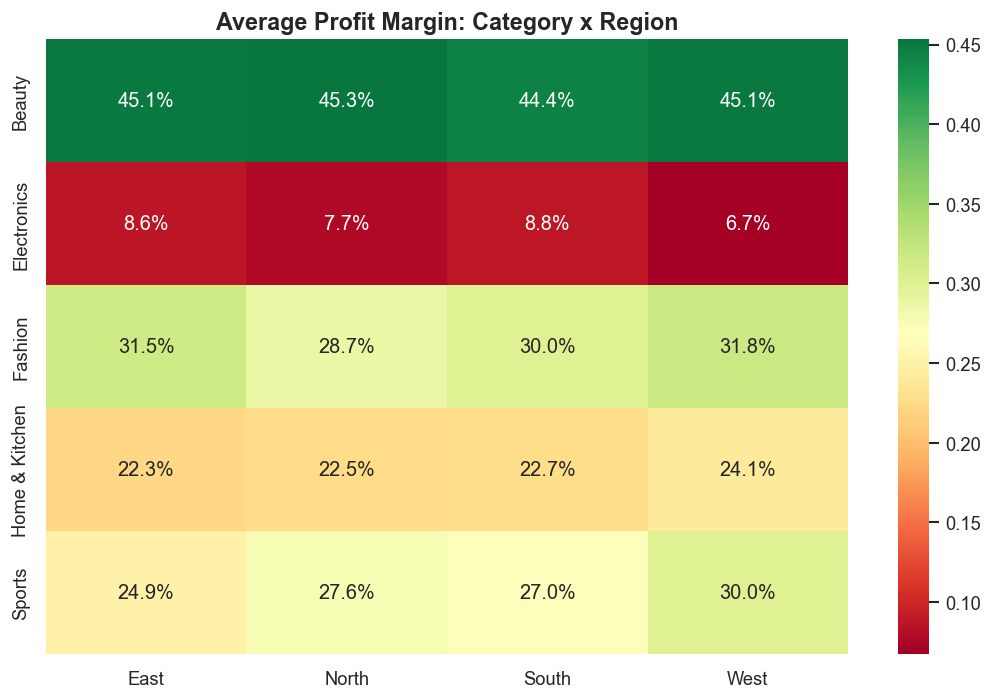

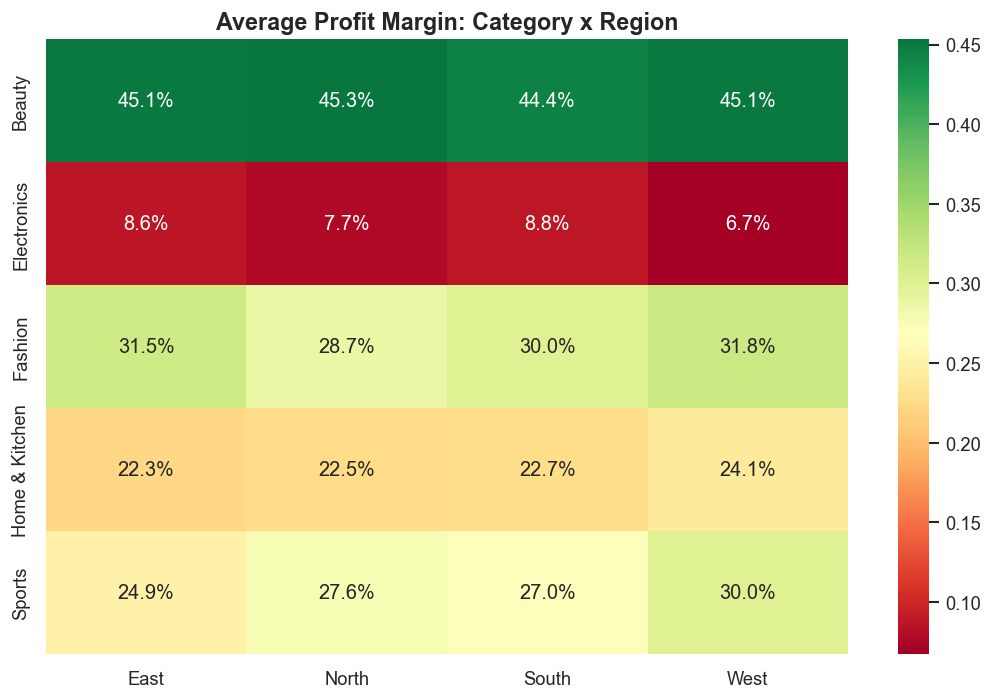

In [19]:
pivot = df.pivot_table(index="category", columns="region",
                       values="profit_margin", aggfunc="mean")
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(pivot, annot=True, fmt=".1%", cmap="RdYlGn",
            center=pivot.values.mean(), ax=ax)
ax.set_title("Average Profit Margin: Category x Region")
ax.set_xlabel("")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(VISUALS_DIR / "07_margin_heatmap.png", dpi=150)
fig


## 5. Conclusion and recommendations

**Key findings:**
1. **Margin-mix risk** — Electronics drives the majority of revenue at a thin
   margin, while high-margin categories like Beauty are under-scaled.
2. **Deep discounts destroy profit** — orders with 21%+ discount have negative
   average margins. Blanket discounting is leaking profit.
3. **A loyal core carries the business** — high repeat rate, and the top 10%
   of customers generate over 40% of revenue.

